In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
RANDOM_SEED = 41

Text(0, 0.5, 'X2')

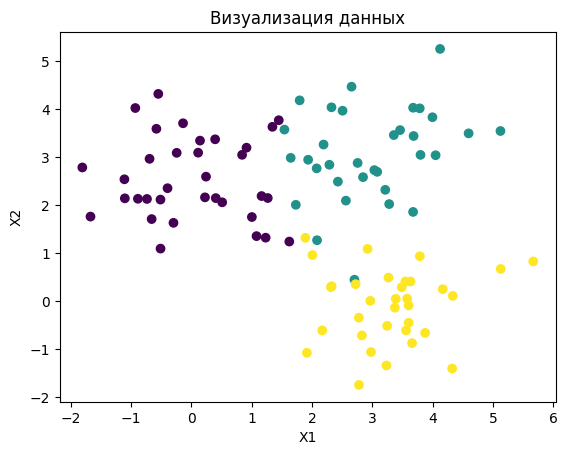

In [2]:
X, y = make_blobs(n_samples=100, centers=[(0,3),(3,3),(3,0)], 
                                      n_features=2, random_state=RANDOM_SEED,
                                      cluster_std=(0.9,0.9,0.9))
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.title('Визуализация данных')
plt.xlabel('X1')
plt.ylabel('X2')

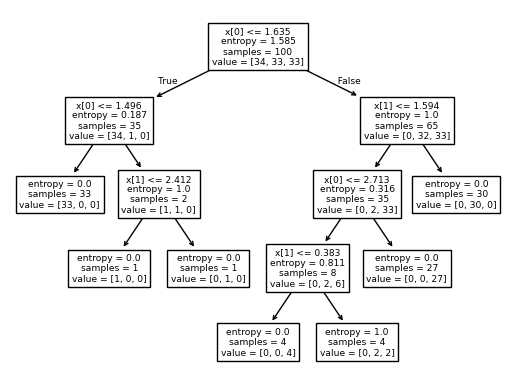

In [3]:
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier

depth=4
clf_tree = DecisionTreeClassifier(criterion='entropy', max_depth=depth, 
                                  random_state=RANDOM_SEED)
clf_tree.fit(X, y)
tree.plot_tree(clf_tree) 
plt.show()

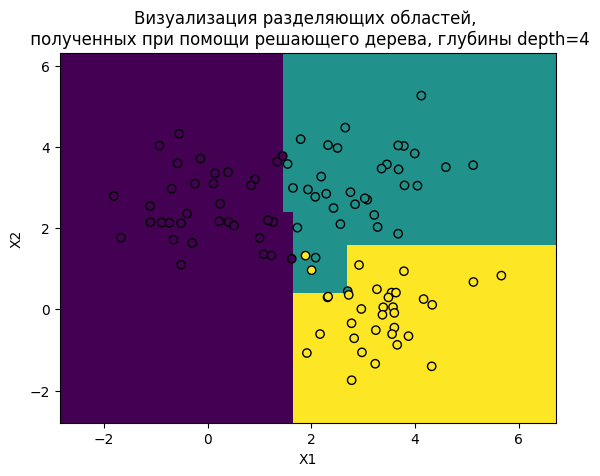

In [4]:
X0 = np.linspace(X[:, 0].min()-1,X[:, 0].max()+1, X.shape[0])
X1 = np.linspace(X[:, 1].min()-1,X[:, 1].max()+1, X.shape[0])
X0_grid, X1_grid = np.meshgrid(X0, X1)

y_predict = clf_tree.predict(np.c_[X0_grid.ravel(),X1_grid.ravel()]).reshape(X0_grid.shape)
plt.pcolormesh(X0_grid, X1_grid, y_predict)

plt.scatter(X[:, 0], X[:, 1], c=y,  edgecolors='black',linewidth=1)

plt.title('Визуализация разделяющих областей, \n полученных при помощи решающего дерева, глубины depth={}'.format(depth))
plt.xlabel('X1')
plt.ylabel('X2')
plt.show()

In [5]:
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score

y_pred = clf_tree.predict(X)
print(confusion_matrix(y, y_pred))
print('Accuracy =', accuracy_score(y, y_pred))
print('F1_score =', f1_score(y, y_pred, average='micro'))

[[34  0  0]
 [ 0 33  0]
 [ 0  2 31]]
Accuracy = 0.98
F1_score = 0.98


In [6]:
observation_new = [[2, 1]]
clf_tree.predict(observation_new)

array([1])

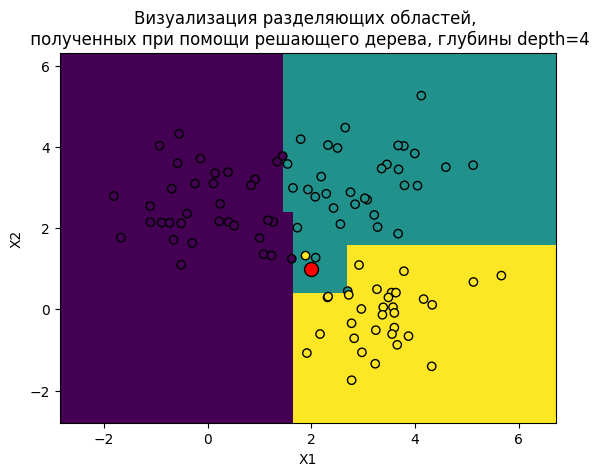

In [7]:
X0 = np.linspace(X[:, 0].min()-1,X[:, 0].max()+1, X.shape[0])
X1 = np.linspace(X[:, 1].min()-1,X[:, 1].max()+1, X.shape[0])
X0_grid, X1_grid = np.meshgrid(X0, X1)

y_predict = clf_tree.predict(np.c_[X0_grid.ravel(),X1_grid.ravel()]).reshape(X0_grid.shape)
plt.pcolormesh(X0_grid, X1_grid, y_predict)

plt.scatter(X[:, 0], X[:, 1], c=y,  edgecolors='black',linewidth=1)

plt.title('Визуализация разделяющих областей, \n полученных при помощи решающего дерева, глубины depth={}'.format(depth))
plt.xlabel('X1')
plt.ylabel('X2')
plt.scatter(observation_new[0][0], observation_new[0][1], c='red', edgecolors='black', linewidth=1, s=100)
plt.show()

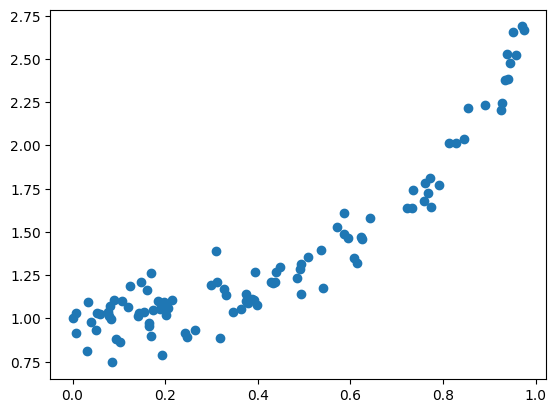

In [8]:
n_samples = 100
X = np.sort(np.random.rand(n_samples))
y = np.exp(X ** 2)+np.random.normal(0.0, 0.1, X.shape[0])
plt.scatter(X, y)
plt.show()

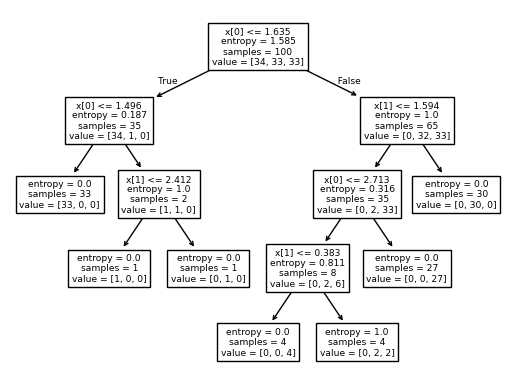

In [9]:
from sklearn.tree import DecisionTreeRegressor
depth=3
X = X.reshape(-1, 1)
reg_tree = DecisionTreeRegressor(max_depth=depth, random_state=RANDOM_SEED)
reg_tree.fit(X, y)
tree.plot_tree(clf_tree) 
plt.show()

Text(0, 0.5, 'y')

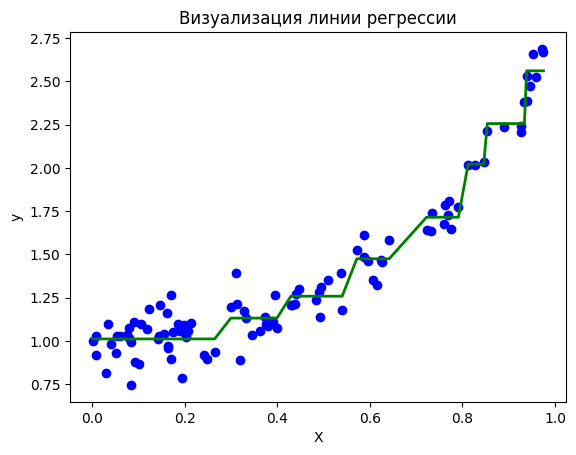

In [10]:
y_pred_reg = reg_tree.predict(X)

plt.scatter(X, y, c="b")

plt.plot(X, y_pred_reg, "g", lw=2)

plt.title('Визуализация линии регрессии')
plt.xlabel('X')
plt.ylabel('y')

In [11]:
from sklearn.metrics import r2_score, mean_squared_error
print('r2= ', r2_score(y, y_pred_reg))
print('MSE= ', mean_squared_error(y, y_pred_reg))

r2=  0.9603455873173242
MSE=  0.009271372788048567


Text(0, 0.5, 'y')

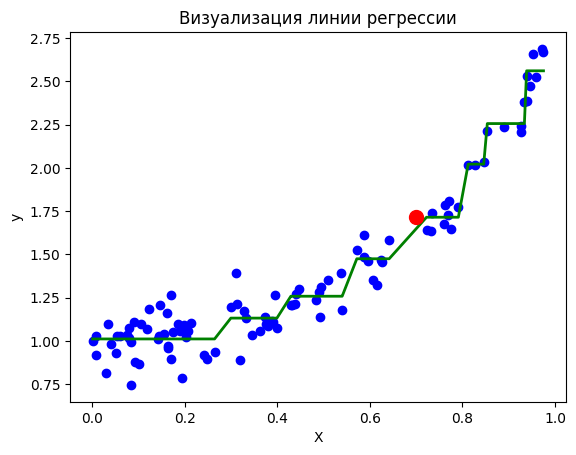

In [12]:
observation_new = [[0.7]]

plt.scatter(X, y, c="b")

plt.plot(X, y_pred_reg, "g", lw=2)
plt.plot(observation_new, reg_tree.predict(observation_new), "ro", markersize=10)

plt.title('Визуализация линии регрессии')
plt.xlabel('X')
plt.ylabel('y')

# tasks

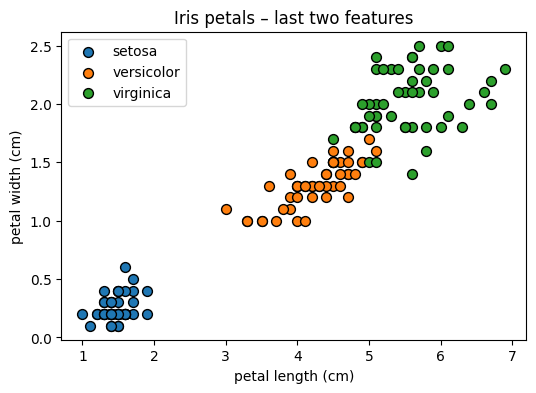

In [13]:
from sklearn import datasets
import matplotlib.pyplot as plt

iris = datasets.load_iris()
X = iris.data[:, 2:]
y = iris.target
names = iris.target_names

plt.figure(figsize=(6, 4))
for idx, name in enumerate(names):
    plt.scatter(X[y == idx, 0], X[y == idx, 1],
                label=name, edgecolor='k', s=50)

plt.xlabel('petal length (cm)')
plt.ylabel('petal width (cm)')
plt.title('Iris petals – last two features')
plt.legend()
plt.show()

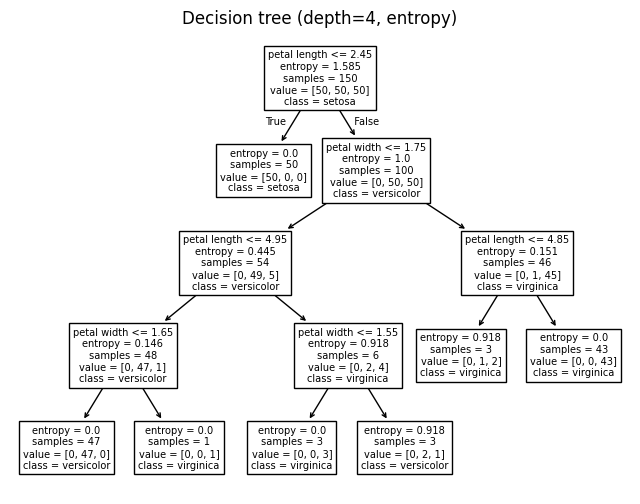

In [14]:
from sklearn import datasets, tree
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt

iris = datasets.load_iris()
X = iris.data[:, 2:]
y = iris.target

depth = 4
clf = DecisionTreeClassifier(criterion='entropy',
                             max_depth=depth,
                             random_state=RANDOM_SEED)
clf.fit(X, y)

plt.figure(figsize=(8, 6))
tree.plot_tree(clf,
               feature_names=['petal length','petal width'],
               class_names=iris.target_names)
plt.title(f"Decision tree (depth={depth}, entropy)")
plt.show()

Depth: 1, Accuracy: 0.67


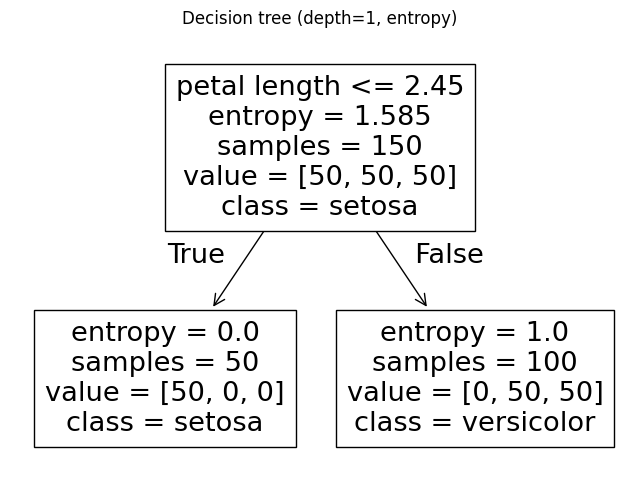

Depth: 2, Accuracy: 0.96


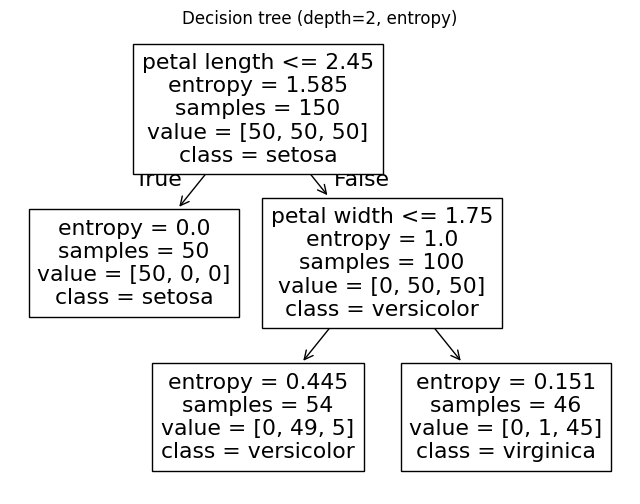

Depth: 3, Accuracy: 0.97


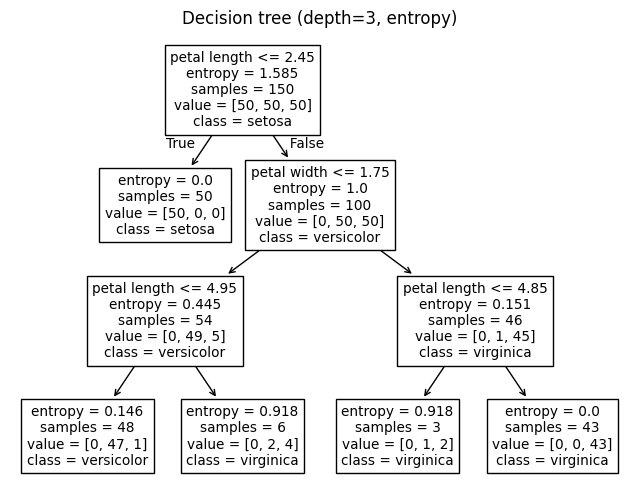

Depth: 4, Accuracy: 0.99


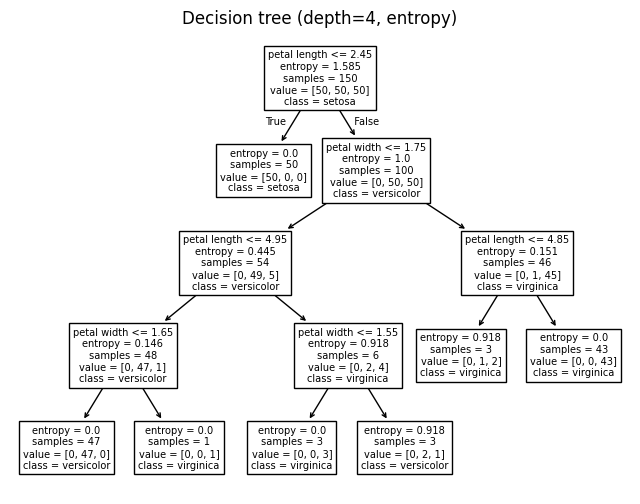

Depth: 10, Accuracy: 0.99


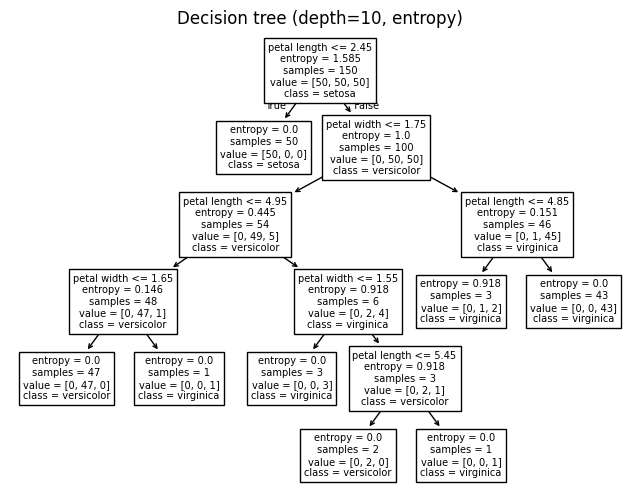

In [15]:
depths = [1, 2, 3, 4, 10]
for depth in depths:
    clf = DecisionTreeClassifier(criterion='entropy',
                                 max_depth=depth,
                                 random_state=RANDOM_SEED)
    clf.fit(X, y)
    plt.figure(figsize=(8, 6))
    accuracy = accuracy_score(y, clf.predict(X))
    print(f"Depth: {depth}, Accuracy: {accuracy:.2f}")
    tree.plot_tree(clf,
                   feature_names=['petal length','petal width'],
                   class_names=iris.target_names)
    plt.title(f"Decision tree (depth={depth}, entropy)")
    plt.show()

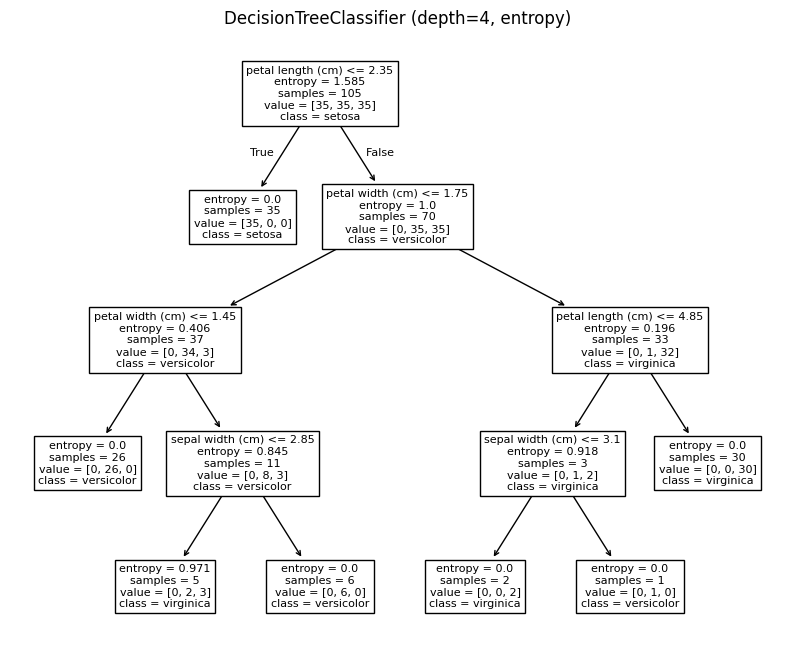

Accuracy: 0.9111111111111111
Confusion matrix:
 [[15  0  0]
 [ 0 13  2]
 [ 0  2 13]]


In [16]:
from sklearn.model_selection import train_test_split

iris = datasets.load_iris()
X, y = iris.data, iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0, stratify=y)

depth = 4
clf = DecisionTreeClassifier(criterion='entropy',
                             max_depth=depth,
                             random_state=41)
clf.fit(X_train, y_train)

plt.figure(figsize=(10, 8))
tree.plot_tree(clf,
               feature_names=iris.feature_names,
               class_names=iris.target_names)
plt.title(f"DecisionTreeClassifier (depth={depth}, entropy)")
plt.show()

y_pred = clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))

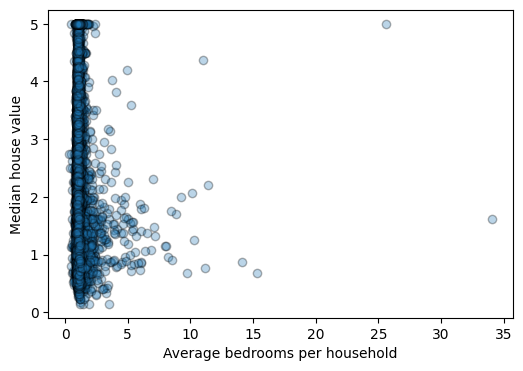

In [17]:
from sklearn import datasets
import matplotlib.pyplot as plt

data = datasets.fetch_california_housing()
X = data.data[:, 3]
y = data.target # median house value

plt.figure(figsize=(6, 4))
plt.scatter(X, y, alpha=0.3, edgecolor='k')
plt.xlabel('Average bedrooms per household')
plt.ylabel('Median house value')
plt.show()

In [18]:
X = X.reshape(-1, 1)
reg = DecisionTreeRegressor(random_state=0)
reg.fit(X, y)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",0
,"max_le

n_nodes: 28439 depth: 80


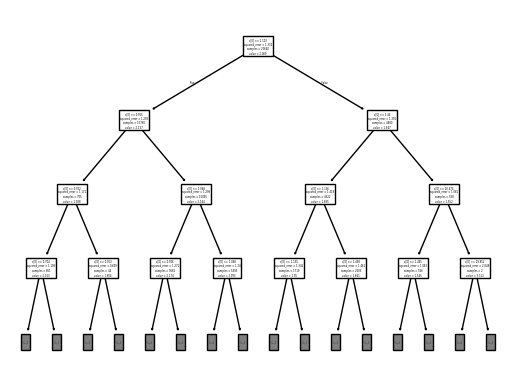

In [19]:
print("n_nodes:", reg.tree_.node_count, "depth:", reg.tree_.max_depth)
tree.plot_tree(reg,
               max_depth=3)
plt.show()

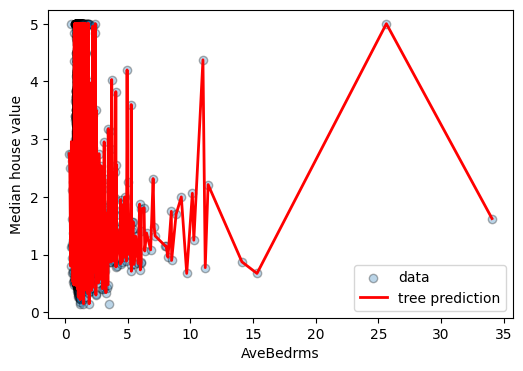

In [20]:
order = np.argsort(X[:,0])
X_sorted = X[order]
y_sorted = y[order]

y_pred = reg.predict(X_sorted)

plt.figure(figsize=(6, 4))
plt.scatter(X_sorted, y_sorted, alpha=0.3, edgecolor='k', label='data')
plt.plot(X_sorted, y_pred, color='r', lw=2, label='tree prediction')
plt.xlabel('AveBedrms')
plt.ylabel('Median house value')
plt.legend()
plt.show()

In [21]:
from sklearn.metrics import r2_score, mean_squared_error

y_pred_all = reg.predict(X)

print("n_nodes:", reg.tree_.node_count, "depth:", reg.tree_.max_depth)
print("R²   :", r2_score(y, y_pred_all))
print("MSE  :", mean_squared_error(y, y_pred_all))

n_nodes: 28439 depth: 80
R²   : 0.679172913720798
MSE  : 0.4271974030094434


In [22]:
new_point = [[0.5]]
print("at", new_point, ":", reg.predict(new_point))

at [[0.5]] : [2.95833667]


node count: 63 depth: 5


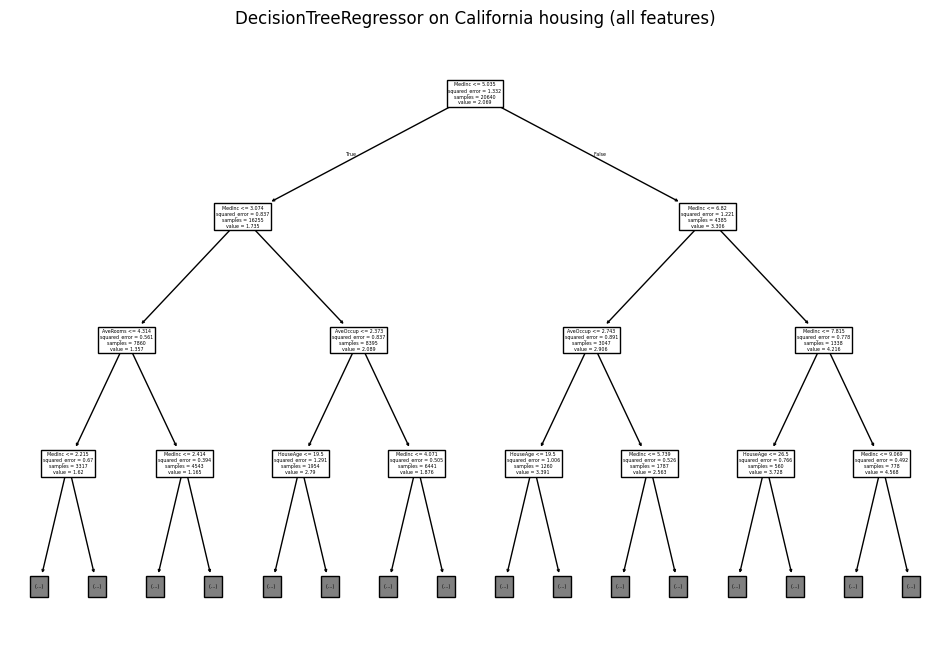

R²   : 0.6315842747781715
MSE  : 0.4905640694739825


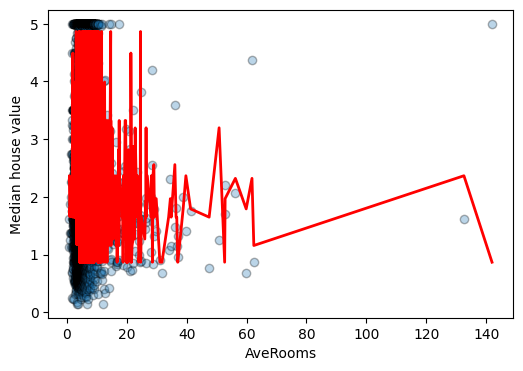

In [27]:
from sklearn import datasets, tree
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np

data = datasets.fetch_california_housing()
X = data.data
y = data.target

reg = DecisionTreeRegressor(random_state=0, max_depth=5)
reg.fit(X, y)

print("node count:", reg.tree_.node_count, "depth:", reg.tree_.max_depth)
plt.figure(figsize=(12, 8))
tree.plot_tree(reg,
               feature_names=data.feature_names,
               max_depth=3)
plt.title("DecisionTreeRegressor on California housing (all features)")
plt.show()

y_pred = reg.predict(X)
print("R²   :", r2_score(y, y_pred))
print("MSE  :", mean_squared_error(y, y_pred))

feat = 2 # just showing 1
order = np.argsort(X[:, feat])
X_sorted = X[order, feat]
y_pred_sorted = reg.predict(X[order])

plt.figure(figsize=(6, 4))
plt.scatter(X_sorted, y[order], alpha=0.3, edgecolor='k', label='data')
plt.plot(X_sorted, y_pred_sorted, color='r', lw=2, label='tree prediction')
plt.xlabel(data.feature_names[feat])
plt.ylabel('Median house value')
plt.show()